# Study 1: Platform as feedback tool

## Libraries

In [ ]:
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
import hdbscan

## 1. Load data, format, and filter by date

In [20]:
df = pd.read_csv("tripadvisor_jfkplaza.csv")

# formate dates of experience
df["date_of_experience"] = pd.to_datetime(df["date_of_experience"], format='%b-%y')


# calculate the proportion of reviews specifiying date of experience
print(1 - df["date_of_experience"].isnull().mean())

0.9227340267459139


In [21]:
# only consider pre-pandemic years
df = df.loc[(df['date_of_experience'] < "2020-03-01")]


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 580 entries, 0 to 642
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   user_name           580 non-null    object        
 1   rating              580 non-null    int64         
 2   user_base           537 non-null    object        
 3   review              580 non-null    object        
 4   date_of_experience  580 non-null    datetime64[ns]
 5   date_written        580 non-null    object        
 6   photos              580 non-null    int64         
 7   party               432 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 40.8+ KB


In [23]:
# Drop reviews with missing dates of experience
df = df.dropna(subset=["date_of_experience"])

## 2. Define study periods

In [24]:
# Core dates
CLOSING_DATE   = pd.Timestamp("2016-02-15")
REOPENING_DATE = pd.Timestamp("2018-05-30")
# https://www.phila.gov/2018-05-30-celebrating-the-return-of-love-park/#:~:text=May%2030%2C%202018%20Moria%20Miller,visit%20the%20redesigned%20park%20include:


# Buffer size in months (on each side)
BUFFER_MONTHS = 1


# Buffer windows to EXCLUDE
# --- Define buffer windows ---
buffer_start_open  = CLOSING_DATE - pd.offsets.MonthBegin(BUFFER_MONTHS)
buffer_end_open    = CLOSING_DATE + pd.offsets.MonthEnd(BUFFER_MONTHS)

buffer_start_close = REOPENING_DATE - pd.offsets.MonthBegin(BUFFER_MONTHS)
buffer_end_close   = REOPENING_DATE + pd.offsets.MonthEnd(BUFFER_MONTHS)



In [25]:
# assign each review to a period

# --- Assign period including buffer ---
def assign_period(d):
    if buffer_start_open <= d <= buffer_end_open:
        return "buffer"
    if buffer_start_close <= d <= buffer_end_close:
        return "buffer"
    if d < buffer_start_open:
        return "before"
    elif buffer_end_open < d < buffer_start_close:
        return "during"
    else:
        return "after"

df["period"] = df["date_of_experience"].apply(assign_period)



In [26]:
df["period"].value_counts()

period
before    339
after     115
during    114
buffer     12
Name: count, dtype: int64

## 3. Period descriptive statistics

### Monthly reviews

In [28]:
# --- Monthly counts ---
monthly = (
    df.groupby([df["date_of_experience"].dt.to_period("M"), "period"])
      .size()
      .reset_index(name="n_reviews")
)

monthly["month_start"] = monthly["date_of_experience"].dt.to_timestamp()

In [29]:
# --- Colors by period ---
period_colors = {
    "before": "#4C72B0",   # blue
    "during": "#DD8452",   # orange
    "after":  "#55A868",   # green
    "buffer": "#B0B0B0"    # grey
}

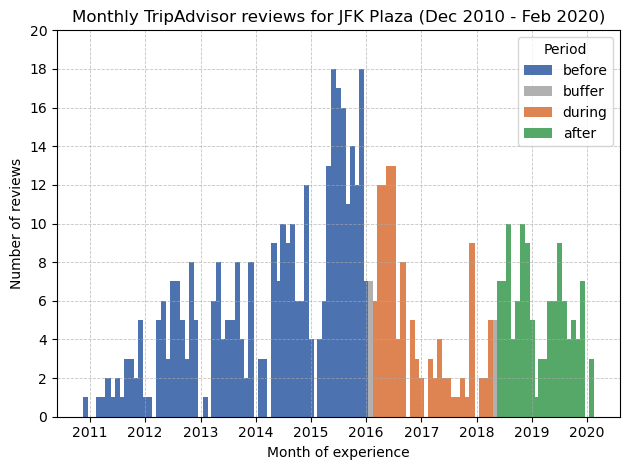

In [30]:
# --- Plot (bar columns) ---
plt.figure()

for period in ['before', 'buffer', 'during', 'after']:
    plt.bar(
        monthly[monthly['period']==period]["month_start"],
        monthly[monthly['period']==period]["n_reviews"],
        width=35,                # approx. one month
        label=period,
        color=period_colors[period]
    )
yint = (0,2,4,6,8,10,12,14,16,18,20)
plt.yticks(yint)

# Add and customize gridlines
plt.grid(
    True,
    color='#AAAAAA',  # A light grey color (hex code)
    linestyle='--',    # Faint dashed lines
    linewidth=0.6,     # Thin lines
    alpha=0.7          # Slightly transparent (0 fully transparent, 1 fully opaque)
)

plt.xlabel("Month of experience")
plt.ylabel("Number of reviews")
plt.title("Monthly TripAdvisor reviews for JFK Plaza (Dec 2010 - Feb 2020)")
plt.legend(title="Period")
plt.tight_layout()

plt.savefig("monthly_reviews.png", dpi=300, bbox_inches='tight')

plt.show()

### Number of photos

In [31]:
df['photos'].describe()

count    580.000000
mean       0.506897
std        1.373932
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       17.000000
Name: photos, dtype: float64

In [32]:
df.groupby('period')['photos'].mean()

period
after     0.965217
before    0.286136
buffer    0.416667
during    0.710526
Name: photos, dtype: float64

In [33]:
df.groupby('period')['photos'].value_counts(normalize = True)

period  photos
after   0         0.626087
        2         0.104348
        3         0.104348
        1         0.095652
        4         0.034783
        6         0.017391
        5         0.008696
        7         0.008696
before  0         0.820059
        1         0.112094
        2         0.044248
        3         0.014749
        5         0.005900
        4         0.002950
buffer  0         0.833333
        1         0.083333
        4         0.083333
during  0         0.771930
        1         0.122807
        2         0.043860
        3         0.017544
        9         0.017544
        6         0.008772
        10        0.008772
        17        0.008772
Name: proportion, dtype: float64

### Party compisition

In [34]:
df.groupby('period')['party'].count()

period
after      85
before    243
buffer      9
during     95
Name: party, dtype: int64

In [35]:
df.groupby('period')['party'].value_counts(normalize=False)

period  party   
after   Couples     33
        Family      26
        Friends     12
        Solo        12
        Business     2
before  Couples     77
        Family      64
        Friends     58
        Solo        30
        Business    14
buffer  Couples      3
        Friends      3
        Business     1
        Family       1
        Solo         1
during  Family      31
        Couples     28
        Friends     18
        Solo        14
        Business     4
Name: count, dtype: int64

### Rating

In [36]:
df.groupby('period')['rating'].value_counts(normalize=True)

period  rating
after   4         0.339130
        5         0.339130
        3         0.234783
        2         0.060870
        1         0.026087
before  4         0.336283
        3         0.333333
        5         0.221239
        2         0.067847
        1         0.041298
buffer  4         0.416667
        3         0.250000
        5         0.250000
        1         0.083333
during  4         0.298246
        5         0.271930
        3         0.236842
        1         0.105263
        2         0.087719
Name: proportion, dtype: float64

## 4. Run BERTopic separately for each period

In [37]:
df

,user_name,rating,user_base,review,date_of_experience,date_written,photos,party,period
0,JennyMfromSC,5,"Charleston, SC",Love Park is an expansive park in Downtown Phi...,2011-04-01,18-Jul-11,0,NaN,before
3,mc2wv0307,4,"Washington DC, DC",Not much to see but the fact that it's love pa...,2011-10-01,07-Nov-11,0,NaN,before
4,EdUrias,5,"San Jose, CA",It was great to learn the history of this park...,2011-11-01,06-Nov-11,0,NaN,before
7,adamsaintlouis,3,"Saint Louis, MO",Love Park (aka JFK Plaza) is fairly center in ...,2011-09-01,12-Sep-11,0,NaN,before
8,Vparry,1,New York City,Homeless people constitute a hefty minority he...,2011-08-01,26-Aug-11,0,NaN,before
...,...,...,...,...,...,...,...,...,...
629,Milton M,4,"Orlando, FL",I had a quick work trip to Philadelphia area a...,2019-11-01,12-Feb-20,0,NaN,after
630,P7525GFjohnl,5,"Arlington, TX",Was awesome to see the Love Sculpture. It was ...,2019-12-01,11-Jan-20,0,NaN,after
631,Marco Buratti,3,"Mondavio, Italy",Good place for couples to take a picture in fr...,2019-11-01,09-Jan-20,0,NaN,after
632,Arnav Bose,5,"Philadelphia, PA",Always love this place. My office is 2 blocks ...,2019-12-01,05-Jan-20,3,Friends,after


In [57]:
# Split data into three (one per period)
docs_all = df['review'].to_list()

docs_period1 = df[df['period'] == 'before']['review'].to_list()
docs_period2 = df[df['period'] == 'during']['review'].to_list()
docs_period3 = df[df['period'] == 'after']['review'].to_list()

### Test model paramters

In [ ]:

embedder = SentenceTransformer("all-MiniLM-L6-v2")

vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9
)

def fit_bertopic(texts, n_neighbors=15, min_dist=0.0, min_cluster_size=10):
    embeddings = embedder.encode(texts, show_progress_bar=False)

    umap_model = UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="cosine",
        random_state=42
    )

    hdbscan_model = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        prediction_data=True
    )

    model = BERTopic(
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer,
        calculate_probabilities=False
    )

    topics, _ = model.fit_transform(texts, embeddings)
    info = model.get_topic_info()

    outlier_share = (pd.Series(topics) == -1).mean()
    n_topics = (info["Topic"] != -1).sum()

    return model, outlier_share, n_topics, info

# Example grid runner for one period
grid = []
texts = df.loc[df["period"] == "before", "review"].tolist()

for mcs in [6, 7, 8, 9, 10]:
    for nn in [10, 15, 20]:
        model, outlier_share, n_topics, info = fit_bertopic(
            texts, n_neighbors=nn, min_dist=0.0, min_cluster_size=mcs
        )
        grid.append({
            "min_cluster_size": mcs,
            "n_neighbors": nn,
            "n_topics": n_topics,
            "outlier_share": outlier_share
        })

pd.DataFrame(grid).sort_values(["outlier_share", "n_topics"])

,min_cluster_size,n_neighbors,n_topics,outlier_share
1,6,15,2,0.014749
6,8,10,3,0.032448
10,9,15,2,0.035398
13,10,15,2,0.038348
9,9,10,3,0.038348
4,7,15,3,0.047198
12,10,10,3,0.047198
7,8,15,3,0.053097
0,6,10,13,0.230088
11,9,20,7,0.250737


Choose `min_cluster_size` = 6 and `n_neighbors` = 10, as it produces the most topics, with an acceptable outlier share. These lower parameters are preferable for our other periods which have far fewer records. 

### Run selected model and get period topics

In [ ]:
# Minimal BERTopic for three pre-split periods

# --- Minimal, stable defaults (good for ~100–350 docs/period) ---
embedder = SentenceTransformer("all-MiniLM-L6-v2")

vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95
)

umap_model = UMAP(
    n_neighbors=10,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=6,
    prediction_data=True
)

def fit_period(docs, period_name):
    # embeddings first (recommended for stability + speed)
    embeddings = embedder.encode(docs, show_progress_bar=True)

    model = BERTopic(
        vectorizer_model=vectorizer,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        calculate_probabilities=False,
        verbose=False
    )

    topics, _ = model.fit_transform(docs, embeddings)

    info = model.get_topic_info()
    info["period"] = period_name
    return model, topics, info

model_before, topics_before, info_before = fit_period(docs_period1, "before")
model_during, topics_during, info_during = fit_period(docs_period2, "during")
model_after,  topics_after,  info_after  = fit_period(docs_period3,  "after")

# --- Quick view: topic tables for each period ---
print("\nBEFORE:\n", info_before.head(15))
print("\nDURING:\n", info_during.head(15))
print("\nAFTER:\n",  info_after.head(15))

# --- Optional: one combined topic-info table you can export ---
topic_info_all = pd.concat([info_before, info_during, info_after], ignore_index=True)
# topic_info_all.to_csv("bertopic_topic_info_by_period.csv", index=False)

# --- Optional: show top words for a specific topic ---
# topic_id = 0
# print(model_before.get_topic(topic_id))

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]


BEFORE:
     Topic  Count                                            Name  \
0      -1     78                 -1_park_fountain_love park_nice   
1       0     62            0_park_philadelphia_philly_love park   
2       1     35   1_christmas_village_christmas village_vendors   
3       2     30                 2_fountain_water_area_sculpture   
4       3     27                 3_park_picture_statue_sculpture   
5       4     22                4_picture_pictures_homeless_nice   
6       5     16   5_skateboarders_homeless_area_homeless people   
7       6     11           6_homeless_homeless people_scary_park   
8       7     11      7_christmas_village_park_christmas village   
9       8     11  8_brotherly love_brotherly_city brotherly_city   
10      9     10                        9_kids_sign_picture_shot   
11     10      9       10_sign_smaller_smaller imagined_imagined   
12     11      9                 11_took_anniversary_photos_park   
13     12      8                    12

In [53]:
topic_info_all

,Topic,Count,Name,Representation,Representative_Docs,period
0,-1,78,-1_park_fountain_love park_nice,"[park, fountain, love park, nice, city, sign, ...","[Despite “selfie sticks,” obviously homeless m...",before
1,0,62,0_park_philadelphia_philly_love park,"[park, philadelphia, philly, love park, city, ...",[LOVE Park (JFK Plaza) is very iconic for Robe...,before
2,1,35,1_christmas_village_christmas village_vendors,"[christmas, village, christmas village, vendor...",[Love Park has undergone quite a beautiful tra...,before
3,2,30,2_fountain_water_area_sculpture,"[fountain, water, area, sculpture, pictures, n...",[It's true there isn't a lot to do here other ...,before
4,3,27,3_park_picture_statue_sculpture,"[park, picture, statue, sculpture, fountain, l...",[I must say I was disappointed with the park b...,before
5,4,22,4_picture_pictures_homeless_nice,"[picture, pictures, homeless, nice, sign, park...",[We stopped here (was one of the stops on a to...,before
6,5,16,5_skateboarders_homeless_area_homeless people,"[skateboarders, homeless, area, homeless peopl...",[Cesspool. Homeless people everywhere. Skatebo...,before
7,6,11,6_homeless_homeless people_scary_park,"[homeless, homeless people, scary, park, reall...",[Not sure why this is getting great reviews. W...,before
8,7,11,7_christmas_village_park_christmas village,"[christmas, village, park, christmas village, ...","[If you feel you must go there, go and take yo...",before
9,8,11,8_brotherly love_brotherly_city brotherly_city,"[brotherly love, brotherly, city brotherly, ci...",[The iconic symbol of LOVE in the city of brot...,before


In [369]:
outlier_share = (pd.Series(topics) == -1).mean()
print("outlier_share:", outlier_share)

outlier_share: 0.16666666666666666


In [401]:
topic_info_all['Representative_Docs'][6]

["Cesspool. Homeless people everywhere. Skateboarders everywhere who run you over and fling their urine soaked boards at innocent bystanders. It smells like feces, urine and weed. Only stop by in the daylight, hold your belongings tight and don't stay for more than 5 minutes. If you have a kid who is headed down the wrong path in life, this would be a good place to bring them and scare them straight.",
 "Growing up in the 80's and 90's skateboarding I was excited to finally go see the iconic Love Park. While it still looks the same as remember from the videos it feels dead. When I was young I would have done anything to go visit this park and watch and feel the electricity in the area. Now its just a area for homeless people and their waste. Shame on the city for letting this happen. They had a chance to put skateboard guidelines in place to keep the youth in the are involved and keep the area alive. Now it is scary at night and scary in the day as well. Hopefully the next time my fami

In [403]:
topic_info_all['Representative_Docs'][24]

["We got engaged at Love Park!! This is a great place to go and visit. In the summer time you can see people sitting around reading a book, enjoying the fountain, some homeless, and great to interact with others. It's a Philly place to see!!",
 'We have enjoyed walking in this park during the daytime and also at night. We love it. Always fun to be here and of course taking our fotos at the LOVE statue! The water fountains are also fun to be around and watch the little kids (and big kids) play in them. A MUST when in the Philly area!',
 'We walked through LOVE Park on our way from our hotel to the Rocky Steps. It is a nice, clean little park in the middle of downtown Philly. There were kids playing in the fountains and parents and young couples milling about. Several cute statues are spread throughout the city block-square park. Definitely a great place to take a break when walking around!']